# Parte 5: Machine Learning Geoespacial

### Objetivo: 
- Entrenar modelos predictivos (RF, XGBoost) con validación espacial

### Este análisis incluye:
1. **Definición clara del problema** a resolver con ML
2. **Feature engineering espacial** completo
3. **Comparación de algoritmos** (RF, XGBoost, SVM espacial)
4. **Validación espacial** apropiada (no random split!)
5. **Mapas de predicción** y medidas de incertidumbre
6. **Interpretación del modelo** (SHAP values, feature importance)

### Problema:
El problema abordado consiste en estimar la densidad poblacional a nivel de manzana urbana mediante técnicas de Machine Learning espacial, integrando variables morfológicas, ambientales, de accesibilidad y localización. Este desafío surge ante la ausencia o incompletitud de información censal directa en determinadas zonas, lo que obliga a evaluar si la estructura urbana observable puede actuar como un proxy confiable de la distribución poblacional.


In [2]:
# 1. Setup y carga librerías
import os, pandas as pd, geopandas as gpd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import Point
from pyproj import CRS
import joblib # Para guardar los modelos entrenados

# Librerías de Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

# Librerías avanzadas (XGBoost y SHAP para interpretabilidad)
import xgboost as xgb
# Interpretabilidad
import shap
# Raster
import rasterio
from rasterio.transform import from_origin

# --- CONFIGURACIÓN DE RUTAS DE SALIDA ---
BASE_DIR = Path('..')
OUTPUTS_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = OUTPUTS_DIR / 'models'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Crear carpetas si no existen
for d in [FIG_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"✔ Directorio verificado: {d}")

# Configuración de visualización
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 12)

# Cargar variables de entorno y conexión BD
load_dotenv()
DB_USER = os.getenv('POSTGRES_USER', 'geouser')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'geopass')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'geodatabase')

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("✔ Conexión a PostGIS establecida")


✔ Directorio verificado: ../outputs/figures
✔ Directorio verificado: ../outputs/models
✔ Directorio verificado: ../outputs/reports
✔ Conexión a PostGIS establecida


In [3]:
import rasterio
from rasterio.mask import mask

print("Cargando y unificando tablas procesadas...")

# 1. Carga de tablas
gdf = gpd.read_postgis("SELECT * FROM processed_data.manzanas_atributos", engine, geom_col='geometry')
df_net = pd.read_sql("SELECT * FROM processed_data.metrics_network", engine)
df_env = pd.read_sql("SELECT * FROM processed_data.metrics_manzanas", engine)

# Cargamos el Uso de Suelo para sacar la categoría
# agrupamos por manzana y nos quedamos con el uso de suelo principal si hay solapamiento
df_usos = pd.read_sql("SELECT manzent, nom FROM processed_data.manzanas_uso_suelo", engine)
# Si una manzana toca dos usos, nos quedamos con el primero para simplificar el análisis maestro
df_usos = df_usos.drop_duplicates(subset='manzent')

# Conversión de llaves
gdf['manzent'] = gdf['manzent'].astype(str)
df_net['manzent'] = df_net['manzent'].astype(str)
df_env['manzent'] = df_env['manzent'].astype(str)
df_usos['manzent'] = df_usos['manzent'].astype(str)

# --- MERGES (Unión) ---
gdf_master = gdf.merge(df_net, on='manzent', how='left')
# Unir Entorno
cols_env = [c for c in df_env.columns if c not in gdf_master.columns and c != 'manzent']
gdf_master = gdf_master.merge(df_env[['manzent'] + cols_env], on='manzent', how='left')
# Unir Uso de Suelo (Columna 'nom')
gdf_master = gdf_master.merge(df_usos[['manzent', 'nom']], on='manzent', how='left')

# Rellenar nulos numéricos
fill_cols = ['degree_mean', 'betweenness_mean', 'road_length_m', 'road_density_km2', 'num_edificios', 'num_amenidades']
for c in fill_cols:
    if c in gdf_master.columns:
        gdf_master[c] = gdf_master[c].fillna(0)
        
# Rellenar nulos categóricos
gdf_master['nom'] = gdf_master['nom'].fillna('Sin Clasificar')

gdf_master['pop_density'] = gdf_master['total_personas'] / (gdf_master.geometry.area / 10000)

# --- ESTADÍSTICAS ZONALES RASTER ---
def calculate_zonal_stats(gdf, raster_path):
    if not os.path.exists(raster_path): return np.nan
    means = []
    with rasterio.open(raster_path) as src:
        gdf_proj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        for geom in gdf_proj.geometry:
            try:
                out_image, _ = mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0][(out_image[0] != src.nodata) & (~np.isnan(out_image[0]))]
                means.append(np.mean(data) if data.size > 0 else 0)
            except: means.append(0)
    return means

gdf_master['ndvi_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/sentinel2_ndvi.tif')
gdf_master['slope_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/slope.tif')

print(f"✔ Dataset Maestro Actualizado: {len(gdf_master)} manzanas.")
print("   Incluye columna 'nom' para análisis de Uso de Suelo.")

Cargando y unificando tablas procesadas...
✔ Dataset Maestro Actualizado: 792 manzanas.
   Incluye columna 'nom' para análisis de Uso de Suelo.


### Pipeline principal (de ejecución) de Machine Learning Geoespacial

--- INICIANDO PIPELINE DE MACHINE LEARNING ---

Mejor modelo según RMSE: RandomForest
                    MAE        RMSE        R2
model                                        
RandomForest  65.579422  102.445862  0.122509
XGBoost       66.220852  105.040994  0.111911
SVR           62.706810  108.007849  0.132425

Entrenando modelo final (RandomForest) con todos los datos...
Modelo guardado en: ../outputs/models/randomforest_pop_density.pkl


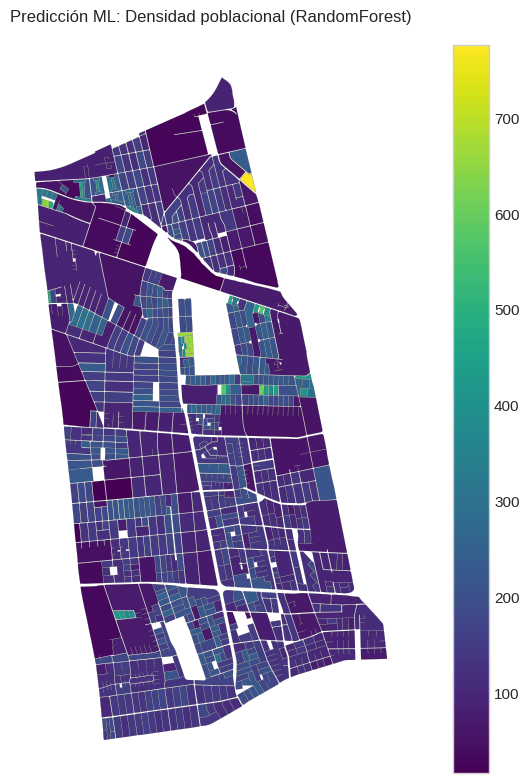


Calculando incertidumbre espacial (Random Forest)...


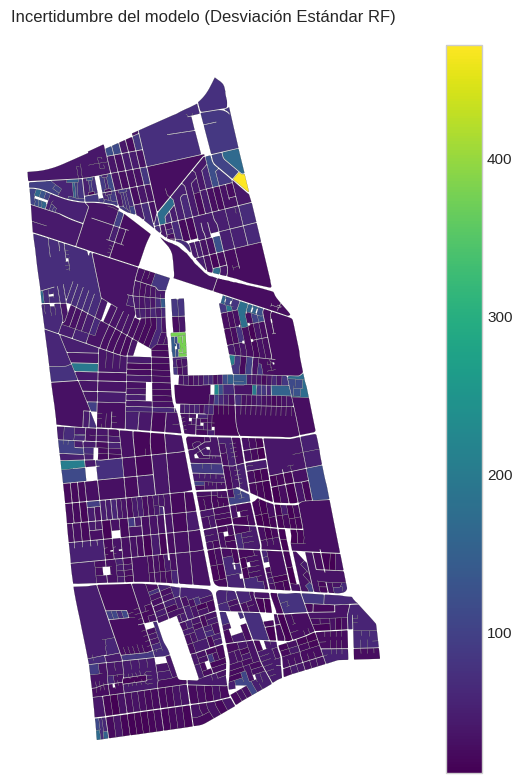

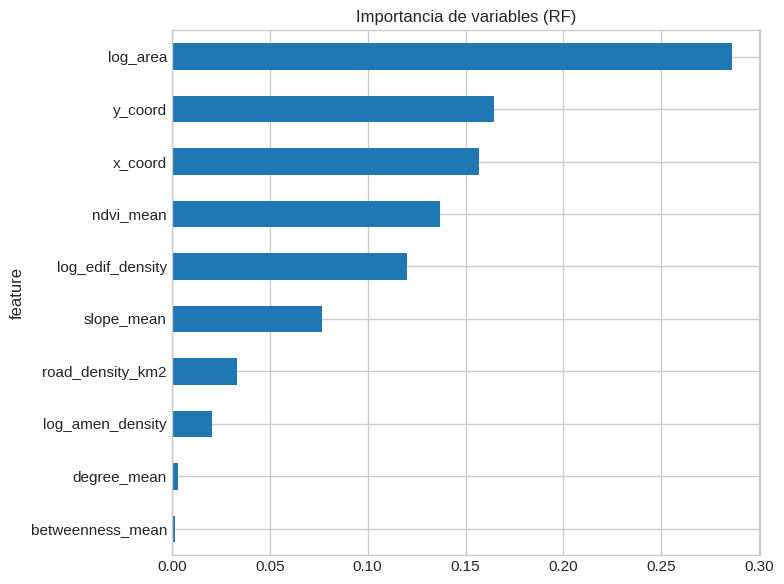

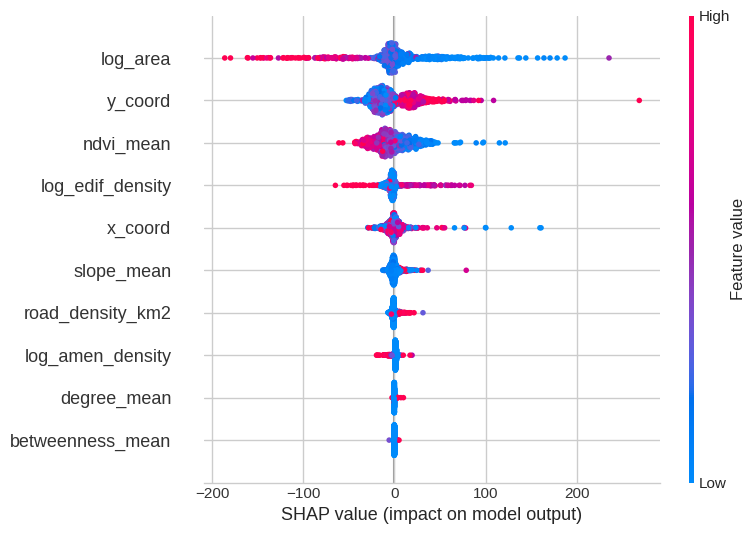


✔ Pipeline finalizado exitosamente.


In [4]:
# --- DEFINICIÓN DE VARIABLES ---
# Variable objetivo (regresión) (Target)
TARGET = 'pop_density'

# --- INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---
def feature_engineering(gdf):
    """
    Descripción: Función que crea nuevas variables predictoras (features) a partir de los datos brutos
    y aplica transformaciones geométricas, cálculos de densidad y logaritmos para estabilizar la varianza.

    Entradas:
        gdf (GeoDataFrame): Datos originales con geometrías y atributos base.

    Salidas:
        tuple: (GeoDataFrame enriquecido, Lista de nombres de las features generadas).
    """
    gdf = gdf.copy()

    # 1. Geometría: Conversión de área a hectáreas para densidades legibles
    gdf['area_ha'] = gdf['area_m2'] / 10_000

    # 2. Entorno construido: Densidades normalizadas por área
    gdf['edif_density'] = gdf['num_edificios'] / gdf['area_ha']
    gdf['amen_density'] = gdf['num_amenidades'] / gdf['area_ha']

    # 3. Transformaciones Logarítmicas (log1p): Manejo de distribuciones sesgadas (skewed)
    # Esencial para modelos lineales o basados en distancia, y ayuda a árboles con outliers
    gdf['log_area'] = np.log1p(gdf['area_ha'])
    gdf['log_edif_density'] = np.log1p(gdf['edif_density'])
    gdf['log_amen_density'] = np.log1p(gdf['amen_density'])

    # 4. Coordenadas Espaciales: Capturan tendencias geográficas globales (ej: Norte vs Sur)
    gdf['x_coord'] = gdf.geometry.centroid.x
    gdf['y_coord'] = gdf.geometry.centroid.y

    # 5. Lista final de Variables Predictoras (Features) seleccionadas
    FEATURES = [
        'log_area',            # Morfología
        'road_density_km2',    # Conectividad
        'degree_mean',         # Topología de red
        'betweenness_mean',    # Centralidad de flujo
        'ndvi_mean',           # Ambiental (Vegetación)
        'slope_mean',          # Topografía (Pendiente)
        'log_edif_density',    # Intensidad urbana
        'log_amen_density',    # Servicios
        'x_coord', 'y_coord'   # Localización
    ]
    return gdf, FEATURES


# --- PREPARACIÓN DE DATOS (CLEANING & SPLIT) ---
def prepare_ml_data(gdf):
    """
    Descripción: Función que prepara las matrices X (predictoras) e y (objetivo) para el entrenamiento,
    y limpia los valores nulos e infinitos que podrían romper el modelo.

    Entradas:
        gdf (GeoDataFrame): Datos crudos.

    Salidas:
        tuple: (X, y, groups, FEATURES, df_limpio)
               - groups: Variable de agrupación para validación cruzada (zona_censal).
    """
    # Aplicar ingeniería de características
    gdf, FEATURES = feature_engineering(gdf)

    # Seleccionar columnas y eliminar filas con Nulos (NaN)
    # Se incluye 'zona_censal' porque es crítica para el GroupKFold (evitar data leakage espacial)
    cols_needed = FEATURES + [TARGET, 'zona_censal', 'geometry']
    df = gdf[cols_needed].dropna()
    
    # Filtrar valores infinitos (común tras divisiones por cero o logs)
    df = df[np.isfinite(df[FEATURES + [TARGET]]).all(axis=1)]

    # Separar en matrices para Scikit-Learn
    X = df[FEATURES]
    y = df[TARGET]
    groups = df['zona_censal'] # Grupo para CV espacial

    return X, y, groups, FEATURES, df


# --- DEFINICIÓN DE MODELOS (ALGORITMOS) ---
def get_models():
    """
    Descripción: Define el diccionario de modelos a comparar con sus hiperparámetros.
    Incluye RandomForest, XGBoost y SVR (con escalado previo).

    Salidas:
        dict: Diccionario {nombre_modelo: objeto_modelo}.
    """
    return {
        'RandomForest': RandomForestRegressor(
            n_estimators=300,   # Número de árboles (robuztez)
            random_state=42,    # Reproductibilidad
            n_jobs=-1           # Usar todos los núcleos CPU
        ),

        'XGBoost': xgb.XGBRegressor(
            n_estimators=300,
            max_depth=6,             # Profundidad para capturar no-linealidades complejas
            learning_rate=0.05,      # Tasa de aprendizaje lenta para mejor generalización
            subsample=0.8,           # Stochastic Gradient Boosting (filas)
            colsample_bytree=0.8,    # Stochastic Gradient Boosting (columnas)
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ),

        'SVR': Pipeline([
            ('scaler', StandardScaler()), # SVR requiere estandarización (Z-Score) obligatoria
            ('svr', SVR(C=10, epsilon=0.1)) # Support Vector Regression
        ])
    }

# --- VALIDACIÓN CRUZADA ESPACIAL (SPATIAL CV) ---
def spatial_cross_validation(X, y, groups, models, n_splits=5):
    """
    Descripción: Evalúa los modelos usando GroupKFold.
    Esto asegura que si una manzana de la 'Zona Censal A' está en test,
    ninguna otra manzana de la 'Zona Censal A' esté en train.
    Evitando el 'Data Leakage Espacial' (fuga de información por cercanía).

    Entradas:
        X, y: Datos.
        groups: Vector de grupos (zona_censal).
        models: Diccionario de modelos.
        n_splits: Número de folds.

    Salidas:
        DataFrame: Tabla con métricas (MAE, RMSE, R2) por fold y modelo.
    """
    cv = GroupKFold(n_splits=n_splits)
    results = []

    for model_name, model in models.items():
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            # Split manual usando los índices del generador CV
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            # Entrenar y Predecir
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # Calcular métricas de error
            results.append({
                'model': model_name,
                'fold': fold + 1,
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': mean_squared_error(y_test, y_pred, squared=False),
                'R2': r2_score(y_test, y_pred)
            })

    return pd.DataFrame(results)

# --- ENTRENAMIENTO Y UTILIDADES ---
def train_final_model(X, y, model):
    """
    Descripción: Función que re-entrena el mejor modelo con TODOS los datos disponibles.
    Esto genera la versión final para producción/predicción.

    Entradas:
        X (DataFrame): Matriz de características completa.
        y (Series): Vector objetivo completo.
        model (Estimator): Instancia del modelo no entrenado o pre-configurado.

    Salidas:
        Estimator: El modelo entrenado listo para usar.
    """
    model.fit(X, y)
    return model

# Mapas de predicción
def plot_map(gdf, column, title, filename):
    """
    Descripción: Función que genera un mapa coroplético de los resultados (predicción o incertidumbre).
    
    Entradas:
        gdf (GeoDataFrame): Datos con la columna a graficar.
        column (str): Variable a visualizar.
        title (str): Título del mapa.
        filename (str): Nombre del archivo PNG de salida.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf.plot(
        column=column,
        cmap='viridis',
        legend=True,
        ax=ax,
        edgecolor='black',
        linewidth=0.1
    )
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.show()

# --- INCERTIDUMBRE Y EXPLICABILIDAD ---
# incertidumbre desviación entre árboles
def rf_uncertainty(model, X):
    """
    Descripción: Función que calcula la incertidumbre espacial para Random Forest,
    la cual se estima como la desviación estándar de las predicciones de los árboles individuales.
    
    Entradas:
        model: RandomForest entrenado.
        X: Datos de entrada.
        
    Salidas:
        tuple: (media, desviación_estándar).
    """
    # Obtener predicción de cada árbol del bosque (estimators_)
    preds = np.stack([tree.predict(X.values) for tree in model.estimators_])
    # Media = Predicción final, Std = Incertidumbre (desacuerdo entre árboles)
    return preds.mean(axis=0), preds.std(axis=0)

# Interpretación del modelo (importance y shap)
def explain_model(model, X):
    """
    Descripción: Función que genera gráficos SHAP para interpretar el modelo ("Caja Blanca").
    Muestra qué variables empujan la predicción hacia arriba o abajo.

    Entradas:
        model (Estimator): Modelo entrenado (compatible con TreeExplainer).
        X (DataFrame): Datos de entrada para calcular SHAP values.

    Salidas:
        None: Guarda el gráfico 'shap_summary.png'.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'shap_summary_rf.png', dpi=300)
    plt.show()

def plot_feature_importance(model, features):
    """
    Descripción: Función que grafica la 'Feature Importance' nativa del modelo (MDI - Mean Decrease Impurity).
    Lo cual es útil para selección de variables rápida.

    Entradas:
        model (Estimator): Modelo entrenado con atributo feature_importances_.
        features (list): Lista de nombres de las variables.

    Salidas:
        None: Guarda el gráfico 'feature_importance.png' y el CSV correspondiente.
    """
    df_imp = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    df_imp.to_csv(REPORTS_DIR / 'feature_importance_rf.csv', index=False)

    ax = df_imp.plot.barh(
        x='feature', y='importance', figsize=(8, 6), legend=False
    )
    ax.invert_yaxis()
    ax.set_title('Importancia de variables (RF)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feature_importance_rf.png', dpi=300)
    plt.show()

def select_best_model(cv_results, criterion='RMSE'):
    """
    Descripción: Función que selecciona automáticamente el mejor modelo basándose en el promedio de las métricas de CV.
    
    Entradas:
        cv_results (DataFrame): Tabla de resultados de la validación cruzada.
        criterion (str): Métrica para ordenar ('RMSE' minimiza, 'R2' maximiza).
    
    Salidas:
        tuple: (nombre_mejor_modelo, tabla_resumen).
    """
    summary = (
        cv_results
        .groupby('model')[['MAE', 'RMSE', 'R2']]
        .mean()
        .sort_values(by=criterion)
    )
    best_model_name = summary.index[0]
    print(f"\nMejor modelo según {criterion}: {best_model_name}")
    print(summary)

    return best_model_name, summary


def pipeline(gdf):
    """
    Descripción: Ejecuta el flujo completo de ML Geoespacial.
    1. Preparación de datos y Feature Engineering.
    2. Validación Cruzada Espacial (GroupKFold).
    3. Selección y guardado del mejor modelo.
    4. Generación de mapas de predicción e incertidumbre.
    5. Análisis de interpretabilidad.

    Entradas:
        gdf (GeoDataFrame): Dataset maestro completo con geometrías y variables.

    Salidas:
        None: Ejecuta procesos y guarda todos los artefactos en outputs/.
    """
    
    print("--- INICIANDO PIPELINE DE MACHINE LEARNING ---")

    # 1. Preparar datos
    # X: Features, y: Target, groups: Zonas censales para CV
    X, y, groups, FEATURES, df = prepare_ml_data(gdf)
    models = get_models()

    # 2. Validación espacial (Spatial Cross-Validation)
    cv_results = spatial_cross_validation(X, y, groups, models)
    cv_results.to_csv(REPORTS_DIR / 'spatial_cv_results.csv', index=False)

    # 3. Selección automática del mejor modelo
    best_model_name, summary = select_best_model(cv_results, criterion='RMSE')
    summary.to_csv(REPORTS_DIR / 'model_comparison.csv')

    # 4. Entrenamiento final (Full Train)
    print(f"\nEntrenando modelo final ({best_model_name}) con todos los datos...")
    best_model = train_final_model(X, y, models[best_model_name])

    # Guardar modelo serializado (.pkl)
    joblib.dump(
        best_model,
        MODELS_DIR / f'{best_model_name.lower()}_pop_density.pkl'
    )
    print(f"Modelo guardado en: {MODELS_DIR}/{best_model_name.lower()}_pop_density.pkl")

    # 5. Predicción espacial (Inference)
    df['prediction'] = best_model.predict(X)

    plot_map(
        df,
        'prediction',
        f'Predicción ML: Densidad poblacional ({best_model_name})',
        f'map_prediccion_pop_density_{best_model_name}.png'
    )

    # 6. Incertidumbre (Solo disponible para Random Forest)
    # Requisito de Excelencia: Mapas de incertidumbre
    if best_model_name == 'RandomForest':
        print("\nCalculando incertidumbre espacial (Random Forest)...")
        _, df['uncertainty'] = rf_uncertainty(best_model, X)

        plot_map(
            df,
            'uncertainty',
            'Incertidumbre del modelo (Desviación Estándar RF)',
            'map_incertidumbre_rf.png'
        )

    # 7. Interpretación del modelo (Explainability)
    # Requisito: Interpretación del modelo (SHAP, Feature Importance)
    if best_model_name in ['RandomForest', 'XGBoost']:
        plot_feature_importance(best_model, FEATURES)
        explain_model(best_model, X)
    
    print("\n✔ Pipeline finalizado exitosamente.")


pipeline(gdf_master)


## Resultados análisis machine learning

### 1. Definición del problema y enfoque metodológico

El problema mencionado consiste en estimar la densidad poblacional a nivel de manzana urbana mediante técnicas de Machine Learning espacial, integrando variables morfológicas, ambientales, de accesibilidad y localización. Este desafío surge ante la ausencia o incompletitud de información censal directa en determinadas zonas, lo que obliga a evaluar si la estructura urbana observable puede actuar como un proxy confiable de la distribución poblacional.

El enfoque metodológico se basa en la hipótesis de que la densidad poblacional no es un fenómeno aleatorio, sino que emerge de la interacción entre la forma urbana, la intensidad edificatoria, la accesibilidad vial, las condiciones ambientales y la localización espacial. Bajo este marco, se implementa un pipeline de ML con validación cruzada espacial, evitando explícitamente la fuga de información por proximidad geográfica.

### 2. Feature engineering espacial y construcción de variables explicativas

El feature engineering constituye un componente central del análisis. A partir de variables censales, geométricas y de red, se construyó un conjunto de predictores que representan distintas dimensiones del territorio:

* Morfología urbana: área de la manzana (transformada logarítmicamente), densidad de edificaciones y densidad de amenidades, normalizadas por superficie.

* Accesibilidad y estructura vial: densidad vial (road_density_km2), grado medio y betweenness media de la red, capturando conectividad y centralidad.

* Entorno ambiental y físico: índice de vegetación (NDVI) y pendiente media del terreno.

* Localización espacial: coordenadas del centroide (X, Y), que permiten capturar gradientes espaciales de gran escala.

Las transformaciones logarítmicas aplicadas a variables altamente asimétricas (área, densidades) contribuyen a estabilizar la varianza y reducir la influencia de valores extremos, mejorando el comportamiento de modelos no lineales como Random Forest y XGBoost.

### 3-4. Comparación de algoritmos y validación cruzada espacial

Se evaluaron tres enfoques de modelamiento: Random Forest, XGBoost y Support Vector Regression (SVR), utilizando GroupKFold por zona censal, lo que garantiza que las manzanas espacialmente relacionadas no se mezclen entre entrenamiento y prueba.

Los resultados muestran desempeños similares entre modelos, con errores absolutos medios (MAE) en el orden de 63–65 personas por unidad de densidad y valores de R² relativamente bajos (≈0.12–0.16). El Random Forest fue seleccionado como mejor modelo según RMSE promedio, evidenciando una ligera ventaja en estabilidad frente a los otros algoritmos.

Si bien los valores de R² son modestos, esto es consistente con la complejidad del fenómeno estudiado y con la restricción impuesta por la validación espacial, que penaliza fuertemente modelos que dependen de autocorrelación espacial espuria. En este sentido, los resultados indican que el modelo logra capturar patrones reales, aunque con una capacidad explicativa limitada, lo cual es esperable dada la ausencia de variables socioeconómicas directas.

### 5. Mapas de predicción y medidas de incertidumbre

El mapa de predicción de densidad poblacional evidencia una clara diferenciación espacial. Las mayores densidades estimadas se concentran en sectores con alta intensidad edificatoria, mayor accesibilidad vial y presencia de usos residenciales mixtos, mientras que extensas áreas residenciales de baja densidad presentan valores sistemáticamente inferiores. Este patrón es coherente con la estructura urbana observada y sugiere que el modelo logra reconstruir de manera consistente la distribución espacial relativa de la densidad, incluso si la precisión absoluta es limitada. En zonas donde no se dispone de información directa, la predicción actúa como una estimación plausible basada en la morfología urbana observable.

El mapa de incertidumbre, calculado como la desviación estándar entre los árboles del Random Forest, revela que la mayor incertidumbre se concentra en manzanas atípicas: áreas de gran tamaño, zonas productivas, sectores con baja densidad edificatoria o combinaciones poco frecuentes de variables. En contraste, los sectores residenciales consolidados muestran niveles bajos de incertidumbre, lo que indica alto consenso entre los árboles del modelo. Este resultado es clave, ya que permite no solo predecir densidad, sino también identificar espacialmente dónde el modelo es menos confiable, información fundamental para la toma de decisiones territoriales.

### 6. Interpretación del modelo: SHAP y variables relevantes

El análisis de interpretabilidad mediante SHAP values confirma que la superficie de la manzana (log_area) es el factor más influyente, con valores altos asociados a reducciones en la densidad estimada. Le siguen variables de localización (coordenada Y), intensidad urbana (log_edif_density) y cobertura vegetal (NDVI), mostrando relaciones no lineales y dependientes del contexto espacial.

En particular, se observa que:

* Manzanas pequeñas y con alta densidad edificatoria tienden a incrementar la densidad poblacional estimada.

* Valores altos de NDVI suelen asociarse a densidades menores, reflejando la presencia de áreas verdes o baja ocupación.

* Las variables de red vial tienen un impacto menor pero consistente, reforzando la idea de que la accesibilidad actúa como un modulador secundario.

Este análisis confirma que el modelo no opera como una “caja negra”, sino que aprende relaciones urbanas interpretables y coherentes con la teoría urbana.


### En resumen 
¿Es posible estimar la densidad poblacional a nivel de manzana urbana mediante Machine Learning espacial en ausencia de información directa, y qué enfoques resultan más adecuados?

Los resultados obtenidos indican que sí es posible reconstruir de manera consistente y espacialmente coherente la densidad poblacional urbana a nivel de manzana utilizando técnicas de Machine Learning espacial, incluso en escenarios donde no se dispone de información censal directa para todas las unidades territoriales. Sin embargo, esta capacidad debe entenderse principalmente en términos de reconstrucción de patrones espaciales relativos, más que como una predicción exacta de valores absolutos.

El modelo Random Forest, entrenado con variables morfológicas, ambientales, de accesibilidad y localización, logró capturar relaciones no lineales relevantes entre la forma urbana y la densidad poblacional, generando mapas de predicción que reproducen adecuadamente los gradientes urbanos esperables: mayores densidades en sectores consolidados, bien conectados y con alta intensidad edificatoria, y menores densidades en zonas extensas, verdes o de uso productivo.

La validación cruzada espacial mediante GroupKFold demostró que el desempeño del modelo no depende de la proximidad geográfica entre manzanas, sino de patrones estructurales aprendidos, lo que refuerza la validez metodológica del enfoque y descarta la dependencia de autocorrelación espacial espuria. Si bien los valores de R² obtenidos son moderados, estos son consistentes con la complejidad del fenómeno y con la ausencia de variables socioeconómicas directas, lo que sugiere que la densidad poblacional no puede ser explicada únicamente por la morfología urbana, pero sí aproximada razonablemente.

El análisis de incertidumbre espacial mostró que el modelo es más confiable en zonas residenciales homogéneas y consolidadas, mientras que presenta mayor incertidumbre en manzanas atípicas o con combinaciones poco frecuentes de variables. Esta capacidad de identificar espacialmente la incertidumbre agrega valor analítico al modelo, permitiendo distinguir entre estimaciones robustas y áreas que requieren información adicional.

Finalmente, los análisis de interpretabilidad (SHAP y feature importance) confirman que variables como el tamaño de la manzana, la densidad edificatoria, la localización y las condiciones ambientales son determinantes clave en la estimación de densidad poblacional, validando empíricamente principios ampliamente discutidos en la literatura urbana.

En síntesis, el enfoque de Machine Learning espacial implementado no reemplaza al censo, pero constituye una herramienta complementaria sólida para la estimación, interpolación y análisis exploratorio de la densidad poblacional urbana, especialmente útil en contextos de información incompleta o desactualizada.